# Evidential Deep Learning - Showcase on MNIST

https://github.com/teddykoker/evidential-learning-pytorch

## What is Evidential Deep Learning?

Evidential Deep Learning (EDL) enables neural networks to quantify uncertainty by modeling outputs as parameters of a Dirichlet distribution over class probabilities.

**Traditional**: logits → softmax → probabilities (single distribution)  
**EDL**: logits → evidence → Dirichlet parameters (α) → distribution over distributions

This allows the model to express both **what it believes** and **how confident** it is in those beliefs.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Load and prepare MNIST dataset

In [3]:
# MNIST dataset statistics
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081
NUM_CLASSES = 10

transform = T.Compose([T.ToTensor(), T.Normalize(mean=(MNIST_MEAN,), std=(MNIST_STD,))])

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

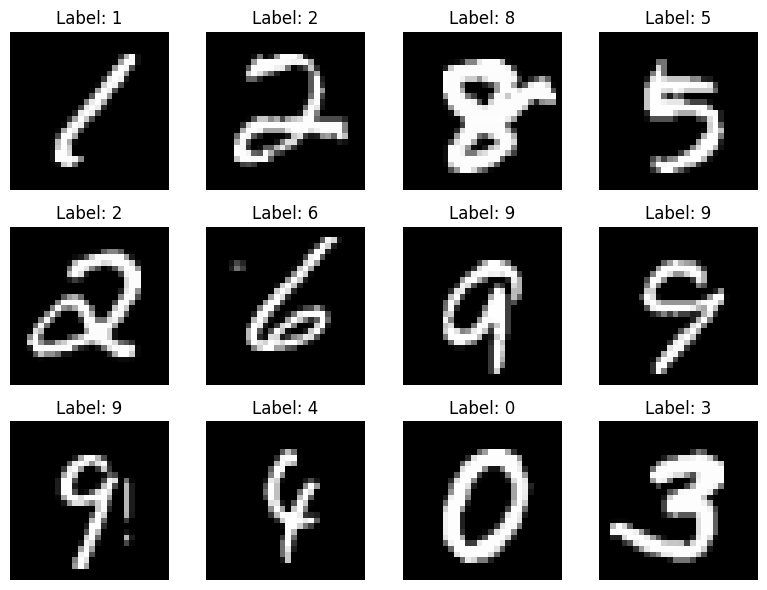

In [4]:
def show_images(images, labels, predictions=None, n_cols=4):
    n_images = len(images)
    n_rows = (n_images + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
    axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

    for i, (image, label) in enumerate(zip(images, labels)):
        img_display = image.reshape(28, 28) * MNIST_STD + MNIST_MEAN
        axes[i].imshow(img_display, cmap="gray", vmin=0, vmax=1)
        
        if predictions is not None:
            pred = predictions[i]
            color = "green" if pred == label else "red"
            axes[i].set_title(f"True: {label.item()}\nPred: {pred.item()}", color=color)
        else:
            axes[i].set_title(f"Label: {label.item()}")
        axes[i].axis("off")

    for i in range(n_images, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    return fig

images, labels = next(iter(train_loader))
show_images(images[:12], labels[:12]);

### Define CNN Architecture

Same architecture for both traditional and EDL training - only the loss function changes.

In [5]:
class TinyCnn(nn.Module):
    
    def __init__(self):
        super(TinyCnn, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.flatten(start_dim=1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

### Training Loop (Traditional)

Train with standard cross-entropy loss as baseline for comparison with EDL.

In [6]:
model = TinyCnn().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch")

    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        progress_bar.set_postfix({"loss": running_loss / (progress_bar.n + 1)})

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            _, predicted = torch.max(model(inputs), dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Epoch 1/3: 100%|██████████| 235/235 [00:08<00:00, 28.64batch/s, loss=0.328]


Validation Accuracy: 97.64%


Epoch 2/3: 100%|██████████| 235/235 [00:08<00:00, 27.25batch/s, loss=0.0887]


Validation Accuracy: 98.49%


Epoch 3/3: 100%|██████████| 235/235 [00:08<00:00, 27.84batch/s, loss=0.0639]


Validation Accuracy: 98.70%


### Evaluate on Test Set

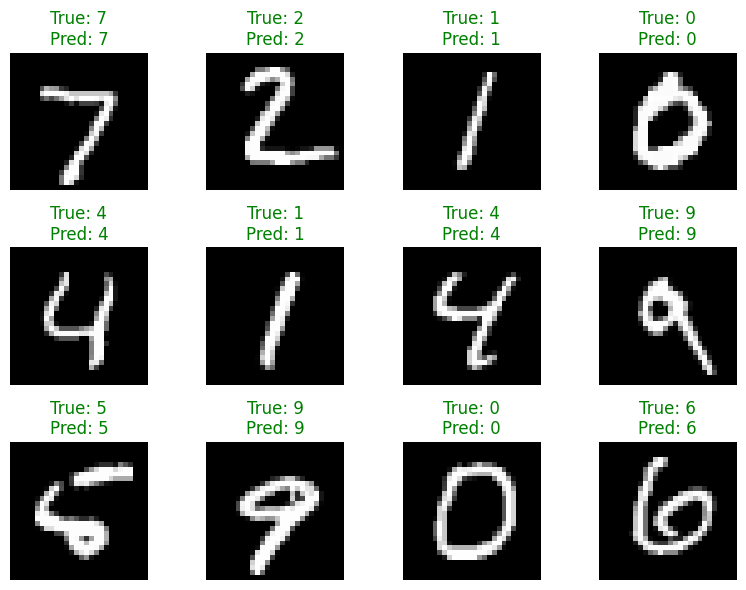

In [7]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits = model(images)
    _, preds = torch.max(logits, dim=1)

show_images(images.cpu()[:12], labels.cpu()[:12], preds.cpu()[:12]);

### Visualize Softmax Probabilities

Probabilities sum to 1, representing the model's confidence distribution.

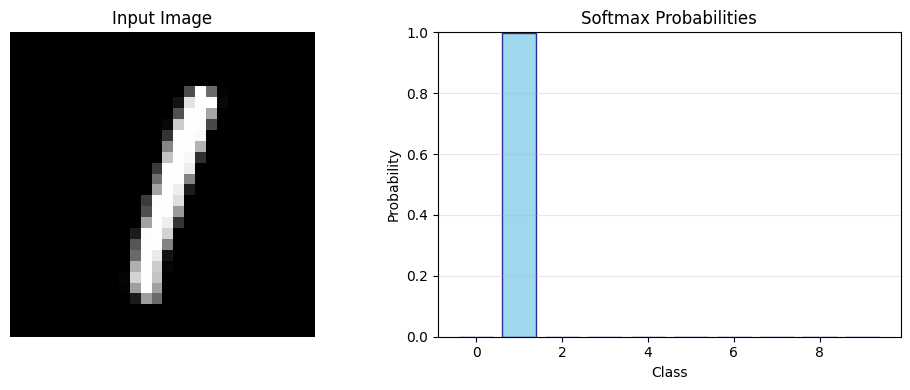

In [8]:
def plot_softmax_probs(probs: torch.Tensor, img: torch.Tensor):
    """Visualize softmax probabilities."""
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    
    img_display = img.reshape(28, 28).cpu() * MNIST_STD + MNIST_MEAN
    axs[0].imshow(img_display, cmap="gray", vmin=0, vmax=1)
    axs[0].set_title("Input Image")
    axs[0].axis("off")

    probs_np = probs.detach().cpu().numpy()
    axs[1].bar(range(len(probs_np)), probs_np, color='skyblue', edgecolor='navy', alpha=0.8)
    axs[1].set_xlabel("Class")
    axs[1].set_ylabel("Probability")
    axs[1].set_ylim(0, 1.0)
    axs[1].set_title("Softmax Probabilities")
    axs[1].grid(axis='y', alpha=0.3)
    
    fig.tight_layout()
    return fig, axs

image = images[5]
probs = F.softmax(logits[5], dim=0)
fig, axs = plot_softmax_probs(probs, image)

### Test on Random Noise

Traditional CNNs confidently predict even on meaningless input, even for noise. 
The model cannot express "I don't know".

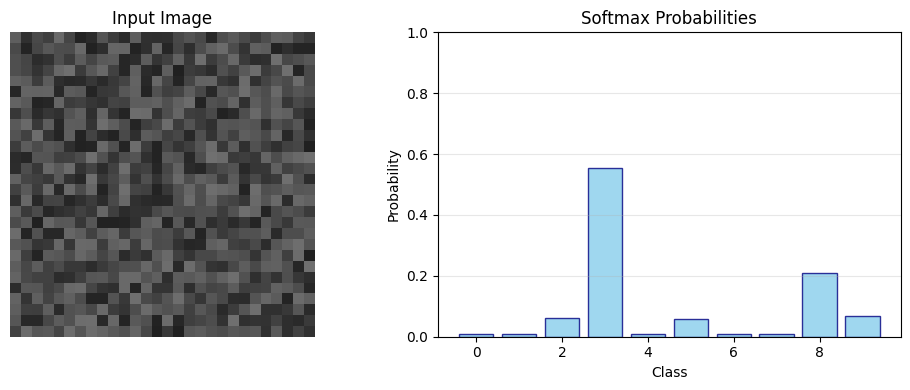

In [9]:
noise_image = torch.rand_like(image)
with torch.no_grad():
    logits = model(noise_image.unsqueeze(0))[0]
    probs = F.softmax(logits, dim=0)
fig, axs = plot_softmax_probs(probs, noise_image)

## Use EDL

### Mathematical Foundation

EDL models output as a **Dirichlet distribution** with parameters $\alpha = [\alpha_1, ..., \alpha_K]$.

**From Logits to Dirichlet:**
1. Evidence: $e_k = \text{softplus}(\text{logit}_k)$ (non-negative)
2. Dirichlet parameters: $\alpha_k = e_k + 1$ (ensures $\alpha_k > 0$)


We add a parameter-free layer to the model to transform outputs into valid dirichlet parameters.

In [10]:
class Dirichlet(nn.Module):
    def forward(self, x):
        evidence = F.softplus(x)
        return evidence + 1.0

model = nn.Sequential(
    TinyCnn(),
    Dirichlet()
).to(device)


**Predictions:**
- Dirichlet strength: $S = \sum_{k=1}^K \alpha_k$ (total evidence)
- Expected probability: $\hat{p}_k = \frac{\alpha_k}{S}$ (mean of Dirichlet)
- Variance: $\text{Var}[p_k] = \frac{\alpha_k(S - \alpha_k)}{S^2(S+1)}$ (epistemic uncertainty)
- Predictive uncertainty: $u = \frac{K}{S}$ (0 = certain, 1 = uncertain)

### EDL Loss Function

**1. MSE Loss:**
$$\mathcal{L}_{\text{MSE}} = \sum_{k=1}^K (y_k - \hat{p}_k)^2 + \sum_{k=1}^K \frac{\hat{p}_k(1-\hat{p}_k)}{S+1}$$

**2. KL Divergence** (suppresses evidence for incorrect classes):
$$\mathcal{L}_{\text{KL}} = \text{KL}[\text{Dir}(\tilde{\alpha}) \| \text{Dir}(\mathbf{1})]$$
where $\tilde{\alpha}_k = y_k + (1-y_k) \cdot \alpha_k$

**3. Annealing:**
$$\mathcal{L} = \mathcal{L}_{\text{MSE}} + \lambda(t) \cdot \mathcal{L}_{\text{KL}}, \quad \lambda(t) = \min(1.0, \frac{t}{T})$$

Gradually increases KL weight from 0 to 1 to allow evidence building before refinement.

In [11]:
def mse_dirichlet(alpha: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """MSE loss for Dirichlet distribution."""
    S = torch.sum(alpha, dim=1, keepdim=True)
    p = alpha / S
    mse_term = torch.sum((y - p) ** 2, dim=1)
    variance_term = torch.sum((p * (1 - p)) / (S + 1), dim=1)
    return torch.mean(mse_term + variance_term)


def kl_dirichlet(alpha: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """KL divergence from suppressed Dirichlet to uniform prior."""
    alpha_tilde = y + (1 - y) * alpha
    beta = torch.ones_like(alpha_tilde)
    
    sum_alpha = torch.sum(alpha_tilde, dim=1)
    sum_beta = torch.sum(beta, dim=1)
    
    t1 = torch.lgamma(sum_alpha) - torch.lgamma(sum_beta)
    t2 = torch.sum(torch.lgamma(alpha_tilde) - torch.lgamma(beta), dim=1)
    t3 = alpha_tilde - beta
    t4 = torch.digamma(alpha_tilde) - torch.digamma(sum_alpha).unsqueeze(1)
    
    kl = t1 - t2 + torch.sum(t3 * t4, dim=1)
    return torch.mean(kl)


def edl_loss(alpha: torch.Tensor, labels: torch.Tensor, 
             epoch: int, num_epochs: int):
    y = F.one_hot(labels, num_classes=NUM_CLASSES).float()   
    mse = mse_dirichlet(alpha, y)
    kl = kl_dirichlet(alpha, y)
    annealing_coef = min(1.0, epoch / max(num_epochs - 1, 1))
    
    return mse + annealing_coef * kl

### Training Loop (EDL)

Same architecture and optimizer - only replace cross-entropy with `edl_loss()`. 

In [12]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch")

    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = edl_loss(model(inputs), labels, epoch, num_epochs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        progress_bar.set_postfix({"loss": running_loss / (progress_bar.n + 1)})

    model.eval()
    correct = total = 0
    total_uncertainty = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Validation Accuracy: {100 * correct / total:.2f}%")


Epoch 1/3: 100%|██████████| 235/235 [00:08<00:00, 27.85batch/s, loss=0.277]


Validation Accuracy: 94.53%


Epoch 2/3: 100%|██████████| 235/235 [00:07<00:00, 29.92batch/s, loss=0.274]


Validation Accuracy: 96.36%


Epoch 3/3: 100%|██████████| 235/235 [00:07<00:00, 31.43batch/s, loss=0.23] 


Validation Accuracy: 95.76%


### Evaluate EDL Model

Accuracy similar to traditional CNN, but now with uncertainty estimates.

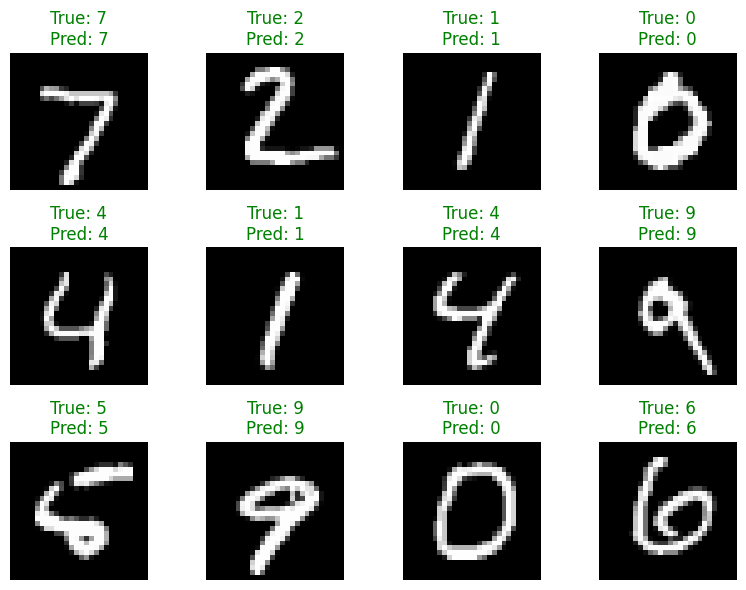

In [13]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits = model(images)
    _, preds = torch.max(logits, dim=1)

show_images(images.cpu()[:12], labels.cpu()[:12], preds.cpu()[:12]);

### Understanding the Visualization

- **Bar heights**: Expected probability ($\alpha_k / S$)
- **Error bars**: Epistemic uncertainty (std deviation)
- **Evidence**: Total evidence ($S - K$)
- **Uncertainty**: $K/S$ (0=certain, 1=uncertain)

In-distribution examples have high evidence and low uncertainty.

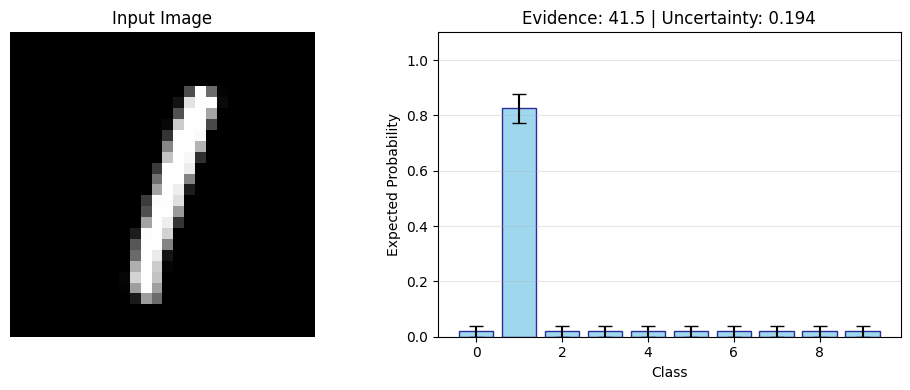

In [14]:
def plot_edl_probs(alpha: torch.Tensor, img: torch.Tensor):
    """Visualize EDL predictions with uncertainty."""
    S = torch.sum(alpha)
    
    probs = (alpha / S).detach().cpu().numpy()
    variance = (alpha * (S - alpha)) / (S ** 2 * (S + 1))
    std_dev = torch.sqrt(variance).detach().cpu().numpy()
    
    uncertainty = NUM_CLASSES / S.item()
    total_evidence = S.item() - NUM_CLASSES
    
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    
    img_display = img.reshape(28, 28).cpu() * MNIST_STD + MNIST_MEAN
    axs[0].imshow(img_display, cmap="gray", vmin=0, vmax=1)
    axs[0].set_title("Input Image")
    axs[0].axis("off")

    axs[1].bar(range(len(probs)), probs, yerr=std_dev, capsize=5, 
               color='skyblue', edgecolor='navy', alpha=0.8)
    axs[1].set_xlabel("Class")
    axs[1].set_ylabel("Expected Probability")
    axs[1].set_ylim(0, 1.1)
    axs[1].set_title(f"Evidence: {total_evidence:.1f} | Uncertainty: {uncertainty:.3f}")
    axs[1].grid(axis='y', alpha=0.3)
    
    fig.tight_layout()
    return fig, axs

image = images[5]
outputs = logits[5]
fig, axs = plot_edl_probs(outputs, image)

### Testing on Out-of-Distribution Data

Mixed image should exhibit high uncertainty (model hasn't seen such examples).

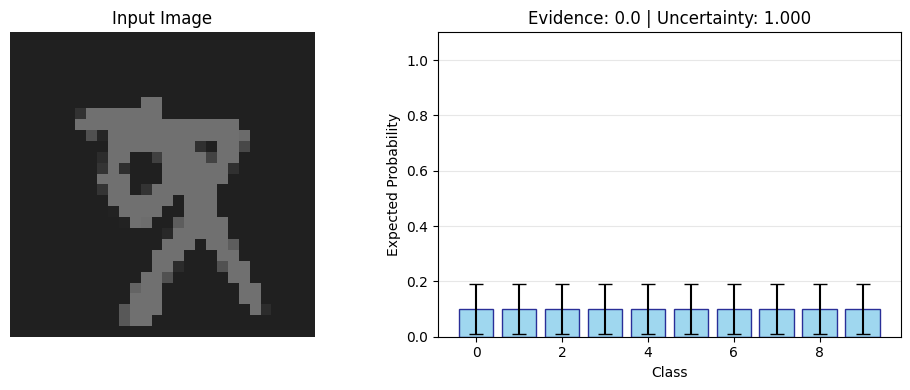

In [15]:
mix_image = torch.clamp((images[0] + images[7]), 0, 1)
with torch.no_grad():
    outputs = model(mix_image.unsqueeze(0))[0]
fig, axs = plot_edl_probs(outputs, mix_image)

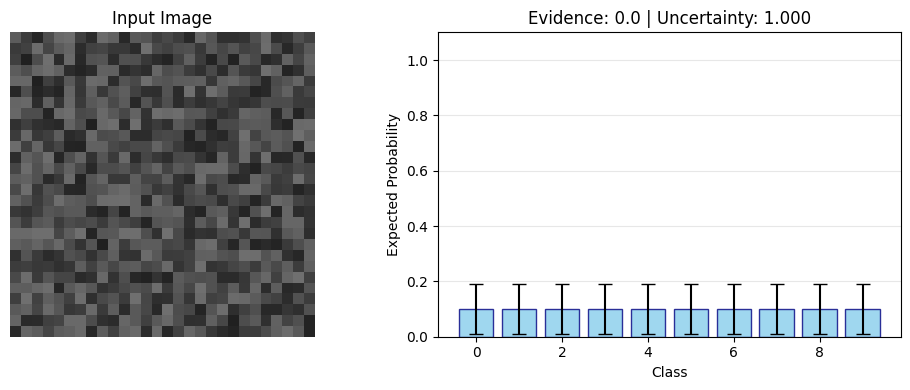

In [16]:
noise_image = torch.rand_like(image)
with torch.no_grad():
    outputs = model(noise_image.unsqueeze(0))[0]
fig, axs = plot_edl_probs(outputs, noise_image)